# CoBas Multimodal Fusion Training

This notebook trains an image + STFT spectrogram fusion model using prepared pipeline outputs. It intentionally does not run video splitting, beacon cropping, audio extraction, STFT generation, or final spectrogram preprocessing. Those steps belong to the processing pipeline; this notebook starts from `Frames/` and `*_Spectogram/*.npy` files.

## Cell 1: Imports, reproducibility, and compute device


In [1]:
from __future__ import annotations

import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms

# Use one seed so dataset splitting and model initialization are repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CUDA will be used automatically when available.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Configuration

Set `SAMPLE_LABELS` to match your training samples. The keys are sample folder names under `Machine Learning/`, and the values are battery classes. Add more folders as the dataset grows.

## Cell 2: Training configuration and fixed class mapping


In [2]:
ML_ROOT = Path.cwd()
if ML_ROOT.name != "Machine Learning":
    ML_ROOT = Path("Machine Learning")

# Keep these labels fixed so model output index 0/1/2 always means 0%/50%/100%.
CLASS_NAMES = ["0%", "50%", "100%"]

# Map each processed sample folder to its real battery class.
# These folders are located in Samples/ and are already in *_Image_and_Video format.
SAMPLE_LABELS = {
    "Samples/0_Percent_Image_and_Video": "0%",
    "Samples/50_Percent_Image_and_Video": "50%",
    "Samples/100_Percent_Image_and_Video": "100%",
}

LABEL_TO_INDEX = {label: index for index, label in enumerate(CLASS_NAMES)}
INDEX_TO_LABEL = {index: label for label, index in LABEL_TO_INDEX.items()}

BATCH_SIZE = 8
EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
VAL_FRACTION = 0.2
TEST_FRACTION = 0.1
# Model weights and label mapping are saved together at the end.
MODEL_OUT = ML_ROOT / "Models" / "multimodal_fusion_model.pth"

LABEL_TO_INDEX


{'0%': 0, '50%': 1, '100%': 2}

## Cell 3: Discover paired frame and spectrogram training samples


In [3]:
@dataclass(frozen=True)
class FusionSample:
    """One aligned multimodal training example from the pipeline output."""

    image_path: Path
    spectrogram_path: Path
    label: int
    sample_name: str
    segment_index: int


def segment_index_from_name(path: Path) -> int:
    """Read the numeric segment index from names like *_seg003.npy or *_frame003.jpg."""

    # Try to extract from _seg or _frame marker
    stem = path.stem
    for marker in ("_seg", "_frame"):
        marker_index = stem.rfind(marker)
        if marker_index != -1:
            return int(stem[marker_index + len(marker):marker_index + len(marker) + 3])
    
    raise ValueError(f"Could not find segment marker in {path.name}")


def find_pipeline_output(sample_dir: Path) -> Path:
    """Find the processed *_Image_and_Video folder inside one sample folder.
    
    If sample_dir itself is already a *_Image_and_Video folder, return it directly.
    """

    # Check if the sample_dir itself is a *_Image_and_Video folder
    if sample_dir.name.endswith("_Image_and_Video") and sample_dir.exists():
        return sample_dir
    
    # Otherwise, look for *_Image_and_Video folders inside it
    candidates = sorted(sample_dir.glob("*_Image_and_Video"))
    if not candidates:
        raise FileNotFoundError(f"No *_Image_and_Video folder found in {sample_dir}")
    return candidates[0]


def get_base_name(path: Path) -> str:
    """Extract base name before _seg or _frame marker."""
    stem = path.stem
    for marker in ("_seg", "_frame"):
        marker_index = stem.rfind(marker)
        if marker_index != -1:
            return stem[:marker_index]
    return stem


def collect_samples(ml_root: Path, sample_labels: dict[str, str]) -> list[FusionSample]:
    """Pair each prepared STFT array with the frame that has the same index."""

    samples: list[FusionSample] = []

    for sample_name, label_name in sample_labels.items():
        sample_dir = ml_root / sample_name
        output_dir = find_pipeline_output(sample_dir)
        frames_dir = output_dir / "Frames"
        spectrogram_dirs = sorted(output_dir.glob("*_Spectogram"))
        if not spectrogram_dirs:
            raise FileNotFoundError(f"No *_Spectogram folder found in {output_dir}")

        spectrogram_dir = spectrogram_dirs[0]
        if label_name not in LABEL_TO_INDEX:
            raise ValueError(f"Unknown label {label_name!r}. Use one of: {CLASS_NAMES}")

        label = LABEL_TO_INDEX[label_name]

        for spec_path in sorted(spectrogram_dir.glob("*.npy")):
            segment_index = segment_index_from_name(spec_path)
            base_name = get_base_name(spec_path)
            # Look for a frame with the same base name and index
            frame_path = frames_dir / f"{base_name}_frame{segment_index:03d}.jpg"
            if not frame_path.exists():
                print(f"[SKIP] Missing frame for {spec_path.name}: {frame_path.name}")
                continue
            samples.append(FusionSample(frame_path, spec_path, label, sample_name, segment_index))

    if not samples:
        raise RuntimeError("No paired frame/spectrogram samples were found.")
    return samples


all_samples = collect_samples(ML_ROOT, SAMPLE_LABELS)
len(all_samples), all_samples[:2]


(415,
 [FusionSample(image_path=PosixPath('/home/deniz/Projects/Research/CoBas/Machine Learning/Samples/0_Percent_Image_and_Video/Frames/0_Percent_beacon_032p57s-310p50s_frame000.jpg'), spectrogram_path=PosixPath('/home/deniz/Projects/Research/CoBas/Machine Learning/Samples/0_Percent_Image_and_Video/0_Percent_Spectogram/0_Percent_beacon_032p57s-310p50s_seg000.npy'), label=0, sample_name='Samples/0_Percent_Image_and_Video', segment_index=0),
  FusionSample(image_path=PosixPath('/home/deniz/Projects/Research/CoBas/Machine Learning/Samples/0_Percent_Image_and_Video/Frames/0_Percent_beacon_032p57s-310p50s_frame001.jpg'), spectrogram_path=PosixPath('/home/deniz/Projects/Research/CoBas/Machine Learning/Samples/0_Percent_Image_and_Video/0_Percent_Spectogram/0_Percent_beacon_032p57s-310p50s_seg001.npy'), label=0, sample_name='Samples/0_Percent_Image_and_Video', segment_index=1)])

## Cell 4: Dataset class and input tensor preparation


In [4]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CoBasFusionDataset(Dataset):
    """Loads RGB frames and prepared STFT arrays for multimodal fusion."""

    def __init__(self, samples: list[FusionSample], image_transform=None):
        self.samples = samples
        self.image_transform = image_transform

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        sample = self.samples[index]

        # Image branch receives normalized 224x224 RGB tensors.
        image = Image.open(sample.image_path).convert("RGB")
        if self.image_transform is not None:
            image = self.image_transform(image)

        # Spectrogram branch receives one channel: (1, frequency_bins, time_steps).
        spectrogram = np.load(sample.spectrogram_path).astype(np.float32)
        spectrogram = np.nan_to_num(spectrogram, nan=0.0, posinf=0.0, neginf=0.0)
        spectrogram = torch.from_numpy(spectrogram).unsqueeze(0)

        label = torch.tensor(sample.label, dtype=torch.long)
        return image, spectrogram, label


dataset = CoBasFusionDataset(all_samples, image_transform=image_transform)
image, spec, label = dataset[0]
image.shape, spec.shape, label

(torch.Size([3, 224, 224]), torch.Size([1, 180, 400]), tensor(0))

## Cell 5: Visualize one paired training sample


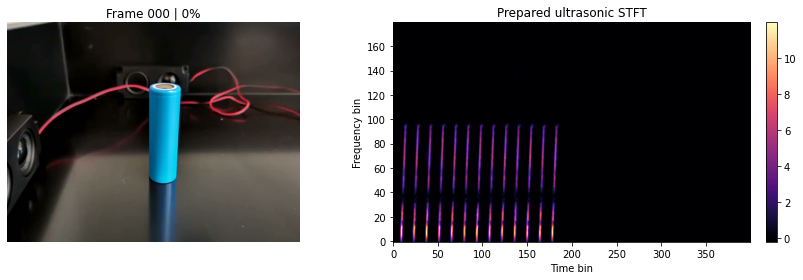

In [5]:
def show_sample_pair(dataset: CoBasFusionDataset, index: int = 0) -> None:
    """Show the paired frame and prepared STFT spectrogram used for one sample."""

    sample = dataset.samples[index]
    image = Image.open(sample.image_path).convert("RGB")
    spectrogram = np.load(sample.spectrogram_path).astype(np.float32)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"Frame {sample.segment_index:03d} | {INDEX_TO_LABEL[sample.label]}")
    axes[0].axis("off")

    im = axes[1].imshow(spectrogram, aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title("Prepared ultrasonic STFT")
    axes[1].set_xlabel("Time bin")
    axes[1].set_ylabel("Frequency bin")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


show_sample_pair(dataset, index=0)


## Cell 6: Train/validation/test split and DataLoaders


In [6]:
def make_loaders(
    dataset: Dataset,
    val_fraction: float = VAL_FRACTION,
    test_fraction: float = TEST_FRACTION,
):
    """Create repeatable train/validation/test splits with stratification to ensure equal class distribution."""

    # Get labels for stratification
    labels = np.array([dataset.samples[i].label for i in range(len(dataset))])
    indices = np.arange(len(dataset))
    
    # First split: separate test set while maintaining class distribution
    test_size = max(1, int(round(len(indices) * test_fraction)))
    train_val_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=SEED,
        stratify=labels,
    )
    
    # Second split: separate validation set from remaining data while maintaining class distribution
    train_val_labels = labels[train_val_indices]
    val_size_ratio = val_fraction / (1 - test_fraction)  # Adjust ratio for remaining data
    val_size = max(1, int(round(len(train_val_indices) * val_size_ratio)))
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=val_size,
        random_state=SEED,
        stratify=train_val_labels,
    )

    train_loader = DataLoader(Subset(dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(Subset(dataset, test_indices), batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders(dataset)
print(f"Train samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

Train samples: 290
Validation samples: 83
Test samples: 42


## Model

This follows the old-code idea: one visual branch, one spectrogram branch, concatenate features, then classify.

## Cell 7: Multimodal fusion model definition


In [7]:
class SpectrogramCNN(nn.Module):
    """Small CNN that converts one STFT spectrogram into a feature vector."""

    def __init__(self, out_features: int = 256):
        super().__init__()
        # Convolutions learn local frequency/time patterns in the ultrasonic STFT.
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.projection = nn.Linear(128, out_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x).flatten(1)
        return self.projection(x)


class MultiModalFusionNet(nn.Module):
    """ResNet image branch + spectrogram CNN branch + fused classifier."""

    def __init__(self, num_classes: int, image_features: int = 256, audio_features: int = 256):
        super().__init__()
        # The old notebooks used ResNet-style visual features; this keeps that concept.
        image_model = models.resnet18(weights=None)
        image_in = image_model.fc.in_features
        image_model.fc = nn.Linear(image_in, image_features)

        self.image_model = image_model
        self.audio_model = SpectrogramCNN(out_features=audio_features)
        # Concatenated image/audio features are mapped to the 0%, 50%, 100% classes.
        self.classifier = nn.Sequential(
            nn.Linear(image_features + audio_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(
        self,
        image: torch.Tensor,
        spectrogram: torch.Tensor,
        return_features: bool = False,
    ):
        image_features = self.image_model(image)
        audio_features = self.audio_model(spectrogram)
        fused = torch.cat([audio_features, image_features], dim=1)
        logits = self.classifier(fused)

        if return_features:
            return audio_features, image_features, fused, logits

        return logits


model = MultiModalFusionNet(num_classes=len(LABEL_TO_INDEX)).to(DEVICE)
sum(p.numel() for p in model.parameters())

11566083

## Cell 8: Feature projection before training


In [8]:
def project_features(features: np.ndarray) -> tuple[np.ndarray, str]:
    """Project features to 2D using t-SNE when possible, otherwise PCA."""

    sample_count = features.shape[0]
    if sample_count < 2:
        return np.zeros((sample_count, 2), dtype=np.float32), "not enough samples"

    if sample_count >= 4:
        perplexity = min(30, max(2, min(sample_count - 1, sample_count // 3)))
        projected = TSNE(
            n_components=2,
            random_state=SEED,
            perplexity=perplexity,
            learning_rate=200.0,
        ).fit_transform(features)
        return projected, f"t-SNE, perplexity={perplexity}"

    projected = PCA(n_components=2, random_state=SEED).fit_transform(features)
    return projected, "PCA"


def extract_feature_arrays(model, loader):
    """Collect audio, image, fused features, labels, and predictions from a loader."""

    model.eval()
    audio_features = []
    image_features = []
    fused_features = []
    labels_all = []
    preds_all = []

    with torch.no_grad():
        for images, spectrograms, labels in loader:
            images = images.to(DEVICE)
            spectrograms = spectrograms.to(DEVICE)
            audio, image, fused, logits = model(images, spectrograms, return_features=True)

            audio_features.append(audio.cpu())
            image_features.append(image.cpu())
            fused_features.append(fused.cpu())
            labels_all.append(labels.cpu())
            preds_all.append(logits.argmax(dim=1).cpu())

    if not fused_features:
        raise RuntimeError("No samples available for feature visualization.")

    return (
        torch.cat(audio_features).numpy(),
        torch.cat(image_features).numpy(),
        torch.cat(fused_features).numpy(),
        torch.cat(labels_all).numpy(),
        torch.cat(preds_all).numpy(),
    )


def visualize_features(model, loader, title_suffix: str = "") -> None:
    """Plot audio, image, and fused feature projections like the old fusion notebook."""

    audio_features, image_features, fused_features, labels_all, _ = extract_feature_arrays(model, loader)
    feature_sets = [audio_features, image_features, fused_features]
    names = ["Audio/STFT", "Image", "Fused"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for features, name, ax in zip(feature_sets, names, axes):
        projected, method = project_features(features)
        for class_index, class_name in INDEX_TO_LABEL.items():
            mask = labels_all == class_index
            if mask.any():
                ax.scatter(projected[mask, 0], projected[mask, 1], s=45, alpha=0.75, label=class_name)
        ax.set_title(f"{name} features {title_suffix} ({method})")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.legend()

    plt.tight_layout()
    plt.show()


## Cell 9: Training and validation loop


In [9]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one pass through a loader; pass an optimizer only for training."""

    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, spectrograms, labels in loader:
        images = images.to(DEVICE)
        spectrograms = spectrograms.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images, spectrograms)
            loss = criterion(logits, labels)

            if is_train:
                # Standard PyTorch update: clear gradients, backprop, then step.
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_count += labels.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


# Cross-entropy expects integer class indices: 0, 1, 2.
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.3f} | "
        f"test loss {test_loss:.4f}, acc {test_acc:.3f}"
    )

Epoch 01/15 | train loss 0.3392, acc 0.966 | val loss 0.0613, acc 1.000 | test loss 0.0652, acc 1.000
Epoch 02/15 | train loss 0.0443, acc 0.993 | val loss 0.0012, acc 1.000 | test loss 0.0012, acc 1.000
Epoch 03/15 | train loss 0.0112, acc 1.000 | val loss 0.0007, acc 1.000 | test loss 0.0007, acc 1.000
Epoch 04/15 | train loss 0.0056, acc 1.000 | val loss 0.0002, acc 1.000 | test loss 0.0002, acc 1.000
Epoch 05/15 | train loss 0.0055, acc 1.000 | val loss 0.0002, acc 1.000 | test loss 0.0002, acc 1.000
Epoch 06/15 | train loss 0.0209, acc 0.997 | val loss 0.0001, acc 1.000 | test loss 0.0001, acc 1.000
Epoch 07/15 | train loss 0.0019, acc 1.000 | val loss 0.0001, acc 1.000 | test loss 0.0001, acc 1.000
Epoch 08/15 | train loss 0.0123, acc 0.997 | val loss 0.0001, acc 1.000 | test loss 0.0001, acc 1.000
Epoch 09/15 | train loss 0.0900, acc 0.979 | val loss 0.0011, acc 1.000 | test loss 0.0012, acc 1.000
Epoch 10/15 | train loss 0.0307, acc 0.990 | val loss 0.0001, acc 1.000 | test los

## Cell 10: Plot training curves


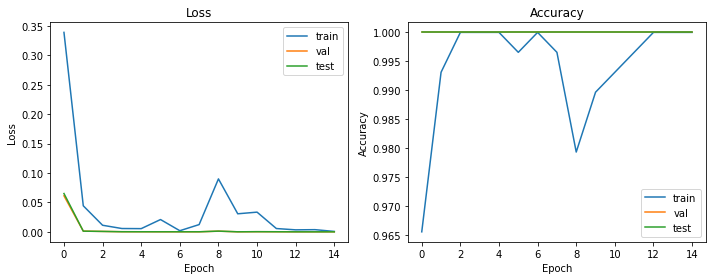

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.plot(history["test_loss"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.plot(history["test_acc"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## Cell 11: Validation/test predictions, reports, and test confusion matrix


Validation classification report
              precision    recall  f1-score   support

          0%       1.00      1.00      1.00        28
         50%       1.00      1.00      1.00        28
        100%       1.00      1.00      1.00        27

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83

Test classification report
              precision    recall  f1-score   support

          0%       1.00      1.00      1.00        14
         50%       1.00      1.00      1.00        14
        100%       1.00      1.00      1.00        14

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



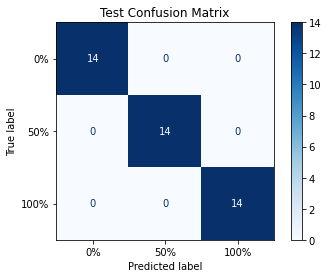

In [11]:
def collect_predictions(model, loader):
    """Collect class predictions from a loader without updating weights."""

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, spectrograms, labels in loader:
            logits = model(images.to(DEVICE), spectrograms.to(DEVICE))
            y_true.extend(labels.numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred)


val_true, val_pred = collect_predictions(model, val_loader)
test_true, test_pred = collect_predictions(model, test_loader)
y_true, y_pred = test_true, test_pred
target_names = [INDEX_TO_LABEL[i] for i in range(len(INDEX_TO_LABEL))]
print("Validation classification report")
print(classification_report(val_true, val_pred, target_names=target_names, zero_division=0))
print("Test classification report")
print(classification_report(test_true, test_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(target_names))))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap="Blues")
plt.title("Test Confusion Matrix")
plt.show()

## Cell 12: Test per-class accuracy and feature projection after training


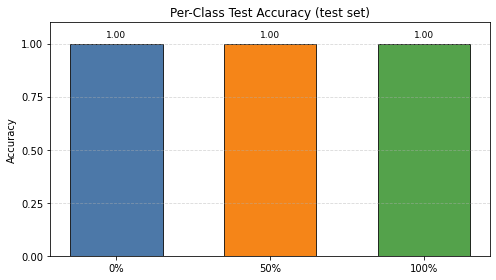

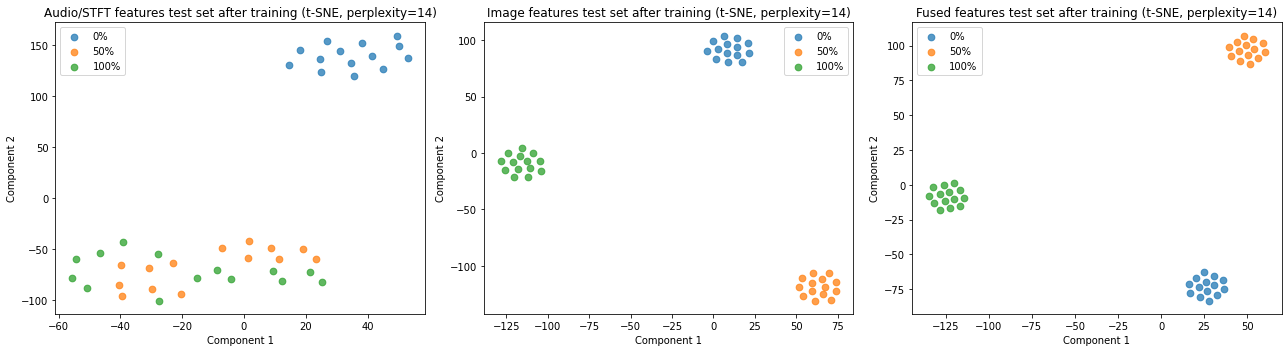

In [12]:
def plot_class_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Plot per-class accuracy using the fixed 0%, 50%, 100% labels."""

    accuracies = []
    class_names = [INDEX_TO_LABEL[index] for index in range(len(INDEX_TO_LABEL))]

    for class_index in range(len(class_names)):
        mask = y_true == class_index

        if mask.any():
            accuracy = float((y_pred[mask] == class_index).mean())
            accuracies.append(accuracy)
        else:
            accuracies.append(np.nan)

    x = np.arange(len(class_names))
    heights = np.array(accuracies, dtype=float)

    fig, ax = plt.subplots(figsize=(7, 4))

    bar_colors = ["#4C78A8", "#F58518", "#54A24B"]
    plot_heights = np.nan_to_num(heights, nan=0.0)

    bars = ax.bar(
        x,
        plot_heights,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.8,
        width=0.6,
    )

    for i, accuracy in enumerate(heights):
        if np.isnan(accuracy):
            bars[i].set_facecolor("#CCCCCC")
            bars[i].set_edgecolor("#666666")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)

    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.10)  # Fix: gives space for labels above 1.00 bars
    ax.set_title("Per-Class Test Accuracy (test set)")

    ax.yaxis.set_major_locator(plt.MultipleLocator(0.25))
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for bar, accuracy in zip(bars, heights):
        if np.isnan(accuracy):
            label = "n/a"
            y_position = 0.02
        else:
            label = f"{accuracy:.2f}"
            y_position = accuracy + 0.02

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_position,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
        )

    plt.tight_layout()
    plt.show()


plot_class_accuracy(y_true, y_pred)
visualize_features(model, test_loader, title_suffix="test set after training")


## Cell 13: Test correctness projection


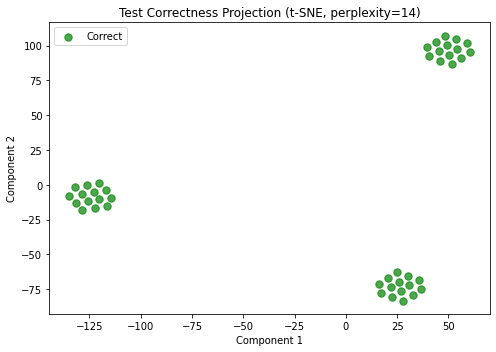

In [13]:
def visualize_correctness_projection(model, loader) -> None:
    """Project fused test features and color points by correct vs wrong prediction."""

    _, _, fused_features, labels_all, preds_all = extract_feature_arrays(model, loader)
    projected, method = project_features(fused_features)
    correct = labels_all == preds_all

    plt.figure(figsize=(7, 5))
    if correct.any():
        plt.scatter(projected[correct, 0], projected[correct, 1], s=55, color="green", alpha=0.7, label="Correct")
    if (~correct).any():
        plt.scatter(projected[~correct, 0], projected[~correct, 1], s=55, color="red", alpha=0.7, label="Wrong")

    plt.title(f"Test Correctness Projection ({method})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


visualize_correctness_projection(model, test_loader)


## Cell 14: Save trained model and label mapping


In [14]:
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_to_index": LABEL_TO_INDEX,
        "index_to_label": INDEX_TO_LABEL,
    },
    MODEL_OUT,
)
MODEL_OUT

PosixPath('/home/deniz/Projects/Research/CoBas/Machine Learning/Models/multimodal_fusion_model.pth')